In [1]:
%load_ext autoreload
%autoreload 2

import re
import warnings
from pathlib import Path

import numpy as np
import unyt as u

import dev
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import richio
from dev import SNAPSHOT_TFB


In [2]:
TIMESERIES_DIR = Path("/home/hey4/rich_tde/data/processed/SimpleTimeseries")

configs = {
    "1e4": {
        "tde": dev.TDEBasics(
            Mbh=1e4 * u.Msun, Mstar=0.5 * u.Msun, Rstar=0.47 * u.Rsun, beta=1
        ),
        "requested_tfbs": [0.5, 1.0, 1.5, 2.0],
    },
    "1e5": {
        "tde": dev.TDEBasics(
            Mbh=1e5 * u.Msun, Mstar=0.5 * u.Msun, Rstar=0.47 * u.Rsun, beta=1
        ),
        "requested_tfbs": [0.3, 0.5],
    },
    "1e6": {
        "tde": dev.TDEBasics(
            Mbh=1e6 * u.Msun, Mstar=1.0 * u.Msun, Rstar=1.0 * u.Rsun, beta=1
        ),
        "requested_tfbs": [1.0, 1.2, 1.4, 1.5],
    },
}

drop_indices = {"1e4": {0, 3}, "1e5": {0}, "1e6": {2, 3}}

for mode, cfg in configs.items():
    selected = [(*SNAPSHOT_TFB(mode, tfb), False) for tfb in cfg["requested_tfbs"]]
    snapnums, paths = dev.DATAPATHS(mode)
    selected.append((snapnums[-1], paths[-1], True))
    cfg["selected"] = [
        item for index, item in enumerate(selected) if index not in drop_indices[mode]
    ]


In [3]:
EDISS_UNIT = "code_length**2*code_mass/code_time**3"


def load_diagnostics(mode):
    ediss = np.loadtxt(TIMESERIES_DIR / f"Ediss-t-{mode}-final.txt", delimiter="\t")
    rdiss = np.loadtxt(TIMESERIES_DIR / f"Rdiss-t-{mode}-final.txt", delimiter="\t")
    return ediss, rdiss


def diagnostic_row(table, snapnum, time_tfb, name):
    same_snapshot = np.flatnonzero(np.rint(table[:, 0]).astype(int) == snapnum)
    candidates = same_snapshot if same_snapshot.size else np.arange(len(table))
    index = candidates[np.argmin(np.abs(table[candidates, 2] - time_tfb))]
    if not same_snapshot.size:
        warnings.warn(
            f"Using nearest {name} row at {table[index, 2]:.3f} t_fb "
            f"for snapshot {snapnum} at {time_tfb:.3f} t_fb",
            stacklevel=2,
        )
    return table[index]


def plotting_coordinates(snap, path, mode, tde):
    path = Path(path)
    plain_snapshot = re.fullmatch(r"snap_\d+\.h5", path.name) is not None
    needs_shift = path.parent.name == "TEMPTDE" if mode == "1e6" else plain_snapshot
    if not needs_shift:
        return snap.X, snap.Y

    offset = dev.reference_frame_offset(
        t=snap.time,
        Mbh=tde.Mbh,
        Mstar=tde.Mstar,
        Rstar=tde.Rstar,
        beta=1,
    )
    return snap.X + offset[0], snap.Y + offset[1]


def rdiss_position(row):
    mean_direction = row[3:6]
    norm = np.linalg.norm(mean_direction)
    if norm == 0:
        return np.full(3, np.nan)
    return row[6] * mean_direction / norm


In [4]:
def plot_mode(mode, res=(512, 512, 256)):
    cfg = configs[mode]
    tde = cfg["tde"]
    ediss_table, rdiss_table = load_diagnostics(mode)
    reference_tde = configs["1e4"]["tde"]
    ramin_over_rp_1e4 = float(
        np.asarray((reference_tde.r_a / reference_tde.r_p).to_value()).squeeze()
    )
    box_in_rp = ramin_over_rp_1e4 * np.array(
        [-1.0, -0.5, -0.5, 0.5, 0.5, 0.5]
    )
    box_size = tde.r_p * box_in_rp

    panels = []
    for snapnum, path, is_last in cfg["selected"]:
        snap = richio.load(path)
        time_tfb = float(np.asarray((snap.time / tde.t_fb).to_value()).squeeze())
        X, Y = plotting_coordinates(snap, path, mode, tde)
        projected, xspace, yspace = snap.project(
            "dissipation", res=res, X=X, Y=Y, Z=snap.Z,
            box_size=box_size, workers=8,
        )

        ediss_row = diagnostic_row(ediss_table, snapnum, time_tfb, "Ediss")
        rdiss_row = diagnostic_row(rdiss_table, snapnum, time_tfb, "Rdiss")
        ediss = u.unyt_array(
            ediss_row[3:7], EDISS_UNIT, registry=richio.units.registry
        ).sum().in_cgs()
        panels.append({
            "snapnum": snapnum, "is_last": is_last, "time_tfb": time_tfb,
            "projected": projected, "xspace": xspace, "yspace": yspace,
            "ediss": ediss, "ediss_row": ediss_row, "rdiss_row": rdiss_row,
            "rdiss_xyz_rp": (
                rdiss_position(rdiss_row) * richio.units.lscale / tde.r_p
            ).to_value(),
        })

    log_projections = []
    for panel in panels:
        values = np.asarray(panel["projected"], dtype=float)
        log_values = np.full(values.shape, np.nan)
        positive = values > 0
        log_values[positive] = np.log10(values[positive])
        log_projections.append(log_values)
    finite = np.concatenate([values[np.isfinite(values)] for values in log_projections])
    vmax = np.ceil(finite.max() * 2) / 2
    vmin = max(np.floor(finite.min() * 2) / 2, vmax - 6)

    nrows, ncols = len(panels), 1
    figsize = (4.0, 1.7 * nrows + 0.45)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, dpi=200, sharex=True, sharey=True,
    )
    axes_grid = np.asarray(axes, dtype=object).reshape(nrows, ncols)
    axes_flat = axes_grid.ravel()
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(cmap(0.0))

    for index, (ax, panel, log_values) in enumerate(
        zip(axes_flat, panels, log_projections)
    ):
        row, col = divmod(index, ncols)
        xgrid, ygrid = np.meshgrid(
            (panel["xspace"] / tde.r_p).to_value(),
            (panel["yspace"] / tde.r_p).to_value(),
            indexing="ij",
        )
        im = ax.pcolormesh(
            xgrid, ygrid, log_values, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True
        )
        rdiss_xyz = panel["rdiss_xyz_rp"]
        ax.plot(
            [0, rdiss_xyz[0]], [0, rdiss_xyz[1]],
            color="white", linewidth=1.1, zorder=9,
        )
        ax.scatter(
            rdiss_xyz[0], rdiss_xyz[1], s=20, color="red",
            edgecolor="white", linewidth=0.45, zorder=10,
        )
        last_label = "last; " if panel["is_last"] else ""
        annotation = (
            last_label + rf"$t={panel['time_tfb']:.2f}\,t_{{\rm fb}}$"
            + "\n"
            + rf"$\dot E_{{\rm diss}}={float(panel['ediss'].to_value()):.2e}\,\mathrm{{erg\,s^{{-1}}}}$"
        )
        ax.text(
            0.025, 0.965, annotation, transform=ax.transAxes,
            color="white", fontsize=7, ha="left", va="top",
            zorder=11,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
        show_x = row == nrows - 1
        show_y = col == 0
        ax.tick_params(
            axis="x", which="both", labelsize=7,
            bottom=show_x, labelbottom=show_x,
        )
        ax.tick_params(
            axis="y", which="both", labelsize=7,
            left=show_y, labelleft=show_y,
        )

    bottom = {2: 0.13, 3: 0.09, 4: 0.07}[nrows]
    top = 0.99
    fig.subplots_adjust(
        left=0.17, right=0.79, bottom=bottom, top=top, hspace=0.015
    )
    cax = fig.add_axes([0.83, bottom, 0.035, top - bottom])
    fig.supxlabel(r"$X\,[R_p]$", x=0.48, y=0.015, fontsize=9)
    fig.supylabel(r"$Y\,[R_p]$", x=0.035, fontsize=9)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(
        r"$\log_{10}[\int \dot{E}_{\rm diss}\,dz\,/"
        r"(\mathrm{erg\,s^{-1}\,cm^{-2}})]$",
        fontsize=8,
    )
    cbar.ax.tick_params(labelsize=7)
    plt.show()
    return fig, axes_grid


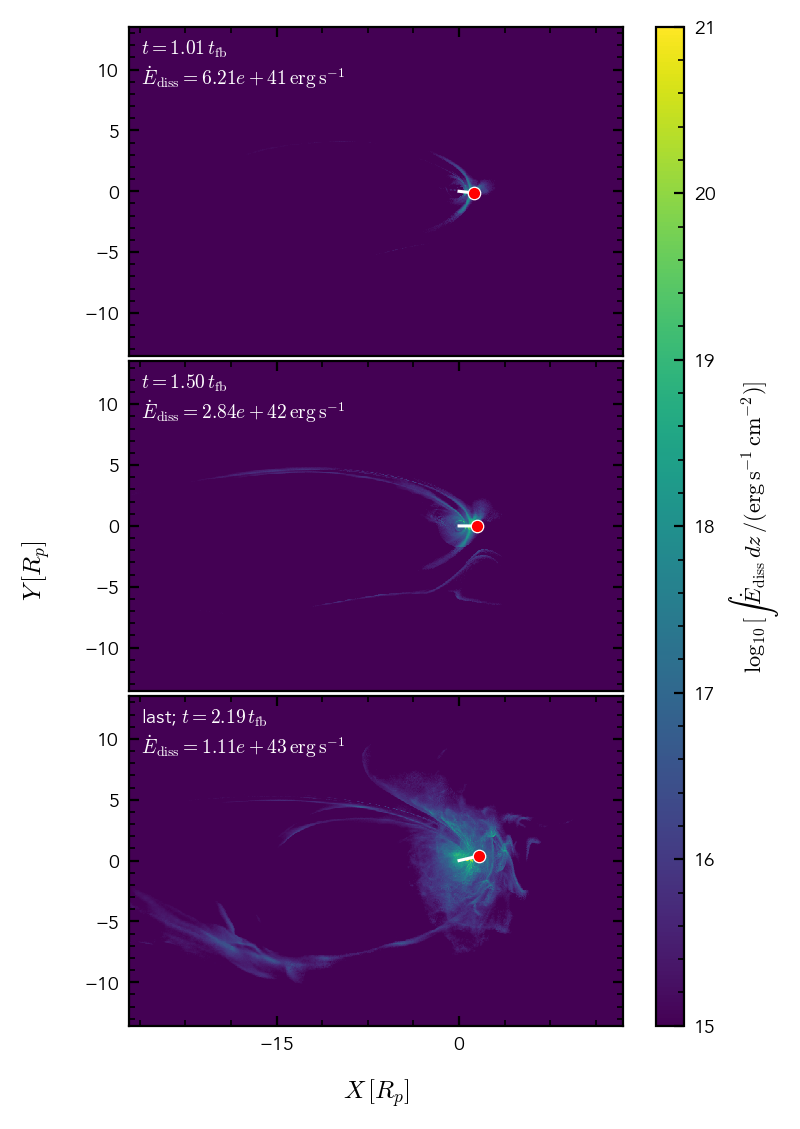

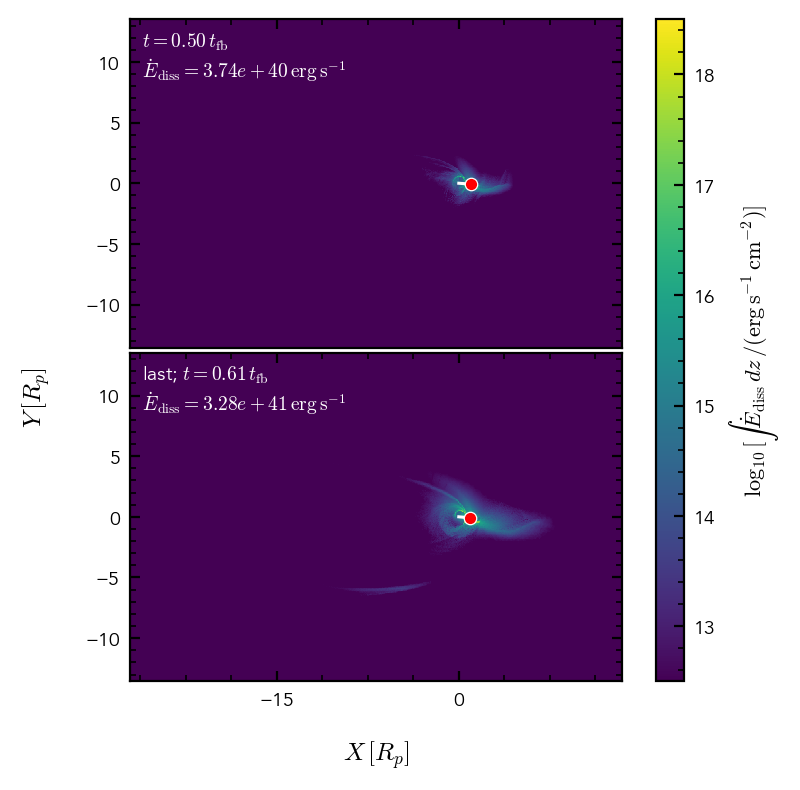

/tmp/ipykernel_3325862/3143999707.py:24: UserWarning: Using nearest Ediss row at 1.491 t_fb for snapshot 1006 at 1.574 t_fb
  ediss_row = diagnostic_row(ediss_table, snapnum, time_tfb, "Ediss")
/tmp/ipykernel_3325862/3143999707.py:25: UserWarning: Using nearest Rdiss row at 1.509 t_fb for snapshot 1006 at 1.574 t_fb
  rdiss_row = diagnostic_row(rdiss_table, snapnum, time_tfb, "Rdiss")


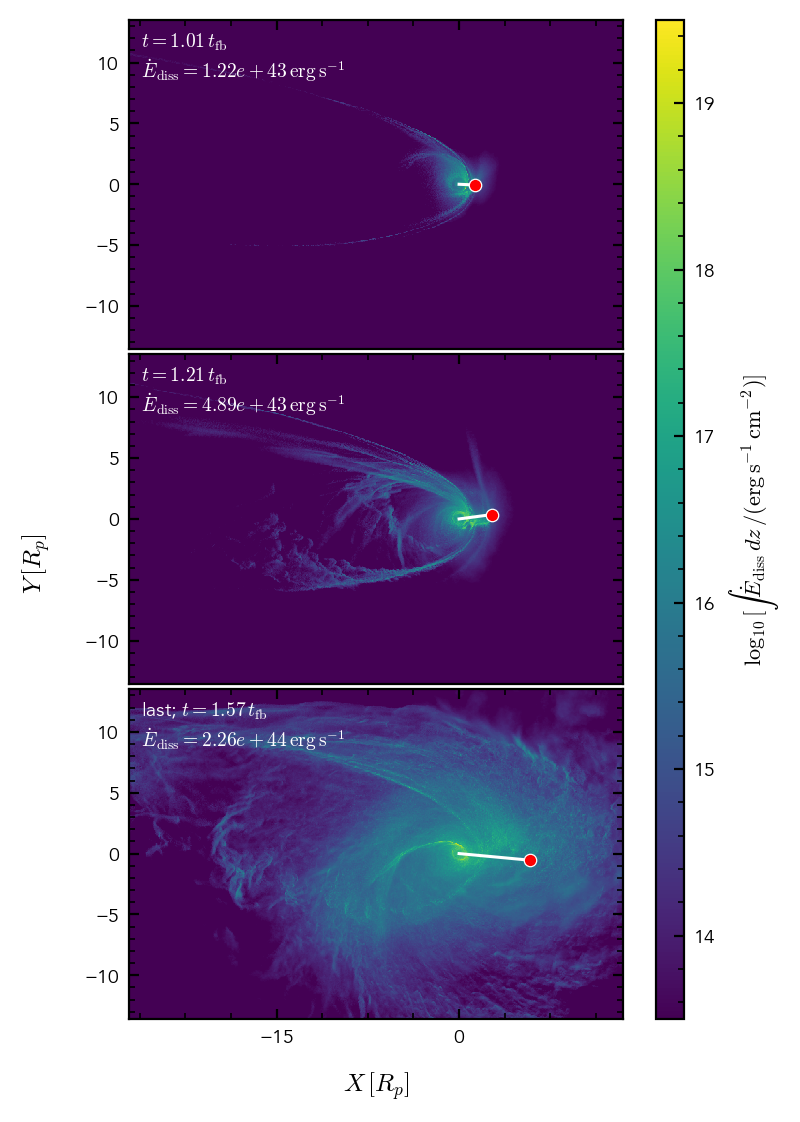

In [5]:
figures = {}
for mode in configs:
    figures[mode] = plot_mode(mode)
